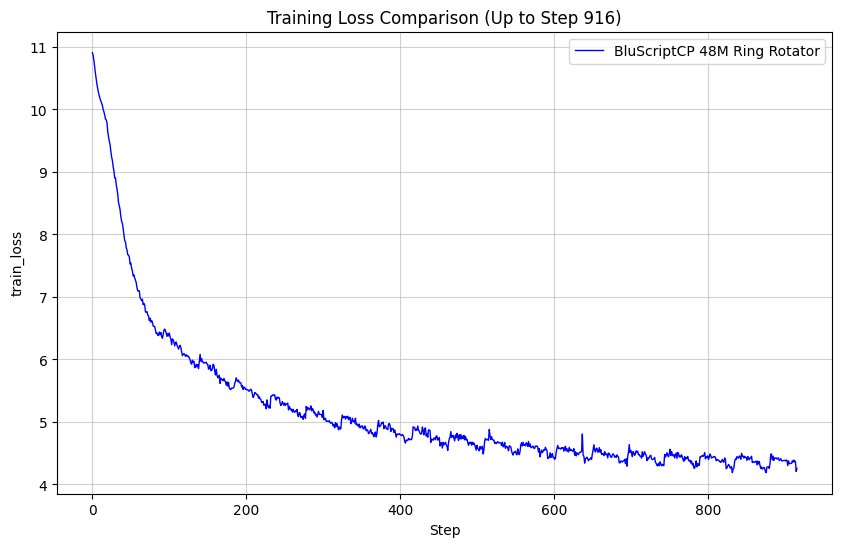

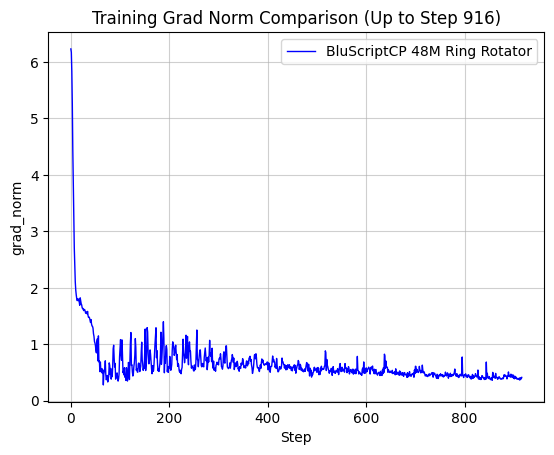

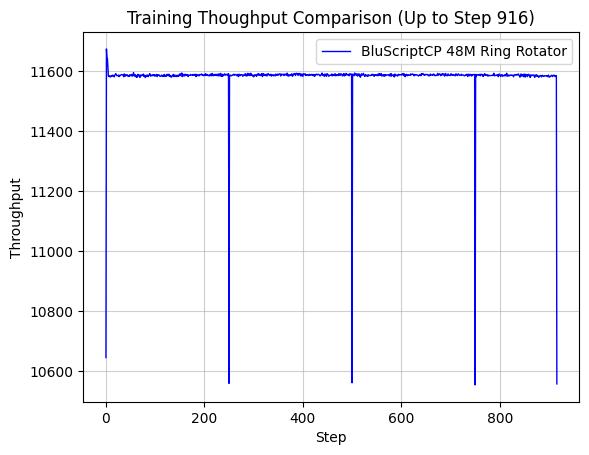

Max. Throughput BluScriptCP 48M Ring Rotator: 11674.623382
Avg. Throughput BluScriptCP 48M Ring Rotator: 11582.07168025736
Min Train Loss BluScriptCP 48M Ring Rotator: 4.187034
Min Val Loss BluScriptCP 48M Ring Rotator: 4.342005
Avg. Time BluScriptCP 48M Ring Rotator: 45269.26466228026
Avg. Data Time BluScriptCP 48M Ring Rotator: 8.928428597600872
Avg. Forward Time BluScriptCP 48M Ring Rotator: 13955.531257437297
Avg. Loss Time BluScriptCP 48M Ring Rotator: 156.2313310883315
Avg. Backward Time BluScriptCP 48M Ring Rotator: 31112.237717525626


In [3]:

import pandas as pd
import matplotlib.pyplot as plt

# plt.style.use('')

# Load datasets
df_new = pd.read_csv('/home/blu-bridge25/CP/CP_Training_logs/CP_Training_log1.csv')
# df_old = pd.read_csv('/home/blu-bridge25/TP/OldPush/TensorParallelismBeta/DTensor/Pytorch/Pytorch_CP_AttnStyle_FP32_Training_logs/Pytorch_CP_AttnStyle_FP32_Training_log41.csv')
# df_3rd = pd.read_csv('/home/blu-bridge25/TP/OldPush/TensorParallelismBeta/DTensor/CP_Training_logs/CP_Training_log162.csv')

if not df_new.empty:
    # df_old.columns = df_old.columns.str.strip()
    df_new.columns = df_new.columns.str.strip()
    # df_3rd.columns = df_3rd.columns.str.strip()

# 1. Get the current progress (max step of the new run)
current_max_step = df_new['step'].max()

# 2 Filter the old run to match the current progress
# df_old_truncated = df_old[df_old['step'] <= current_max_step]
# # # df_3rd_truncated = df_3rd[df_3rd['step'] <= current_max_step]

# 3. Plotting
plt.figure(figsize=(10, 6))

plt.plot(df_new['step'], df_new['train_loss'], label='BluScriptCP 48M Ring Rotator', linewidth=1, color = 'blue')
# # plt.plot(df_old_truncated['step'], df_old_truncated['train_loss'], label='Pytorch CP run (161M)',linewidth = 1, linestyle = "--", color = "red", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['train_loss'], label='Our CP run before (161M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)

plt.xlabel('Step')
plt.ylabel('train_loss')
plt.title(f'Training Loss Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)


plt.savefig('comparison_curve.png')
plt.show()

plt.plot(df_new['step'], df_new['grad_norm'], label='BluScriptCP 48M Ring Rotator', linewidth=1, color = 'blue')
# # plt.plot(df_old_truncated['step'], df_old_truncated['grad_norm'], label='Pytorch CP run (161M)',linewidth = 1, linestyle = "--", color = "red", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['grad_norm'], label='Our CP run before (161M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)


plt.xlabel('Step')
plt.ylabel('grad_norm')
plt.title(f'Training Grad Norm Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)

plt.show()

plt.plot(df_new['step'], df_new['tok_per_sec'], label='BluScriptCP 48M Ring Rotator', linewidth=1, color = 'blue')
# # plt.plot(df_old_truncated['step'], df_old_truncated['tok_per_sec'], label='Pytorch CP run (161M)',linewidth=1, linestyle = "--", color = "red", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['tok_per_sec'], label='Our CP run before (161M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.8)

plt.xlabel('Step')
plt.ylabel('Throughput')
plt.title(f'Training Thoughput Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)
plt.savefig('comparison_curve.png')
plt.show()

print("Max. Throughput BluScriptCP 48M Ring Rotator:",df_new['tok_per_sec'].max())
print("Avg. Throughput BluScriptCP 48M Ring Rotator:",df_new['tok_per_sec'].mean())
print("Min Train Loss BluScriptCP 48M Ring Rotator:",df_new['train_loss'][:].min())
print("Min Val Loss BluScriptCP 48M Ring Rotator:",df_new['val_loss'].where(df_new['val_loss']!=(-1)).min())
print("Avg. Time BluScriptCP 48M Ring Rotator:",df_new['dt_ms'].mean())
print("Avg. Data Time BluScriptCP 48M Ring Rotator:",df_new['timer_data'][:].mean())
print("Avg. Forward Time BluScriptCP 48M Ring Rotator:",df_new['timer_fwd'][:].mean())
print("Avg. Loss Time BluScriptCP 48M Ring Rotator:",df_new['timer_loss'][:].mean())
print("Avg. Backward Time BluScriptCP 48M Ring Rotator:",df_new['timer_bwd'][:].mean())
# print("Avg. Attention Time BluScriptCP 48M Ring Rotator:",df_new['timer_attn_cp'][:].mean())
# print("Avg. clip_grad Time BluScriptCP 48M Ring Rotator:",df_new['timer_clip'][:].mean())
# print("Avg. Optimizer Time BluScriptCP 48M Ring Rotator:",df_new['timer_optim'][:].mean())
# print("Avg. Tok_Emb Time BluScriptCP 48M Ring Rotator:",df_new['timer_tok_emb'][:].mean())
# print("Avg. Pos_Emb Time BluScriptCP 48M Ring Rotator:",df_new['timer_pos_emb'].mean())
# print("Avg. Mlp Time BluScriptCP 48M Ring Rotator:",df_new['timer_mlp'][:].mean())
# print("Avg. Ln_f Time BluScriptCP 48M Ring Rotator:",df_new['timer_ln_f'][:].mean())
# print("Avg. LM Head Time BluScriptCP 48M Ring Rotator:",df_new['timer_lm_head'][:].mean())


# print("\nMax. Throughput Pytorch CP run (161M):",df_old_truncated['tok_per_sec'].max())
# print("Avg. Throughput Pytorch CP run (161M):",df_old_truncated['tok_per_sec'].mean())
# print("Min Train Loss Pytorch CP run (161M):",df_old_truncated['train_loss'][:].min())
# # print("Min Val Loss Pytorch CP run (161M):",df_old_truncated['val_loss'].where(df_old_truncated['val_loss']!=(-1)).min())
# print("Avg. Time Pytorch CP run (161M):",df_old_truncated['dt_ms'].mean())
# print("Avg. Data Time Pytorch CP run (161M):",df_old_truncated['timer_data'][:].mean())
# print("Avg. Forward Time Pytorch CP run (161M):",df_old_truncated['timer_fwd'][:].mean())
# print("Avg. Loss Time Pytorch CP run (161M):",df_old_truncated['timer_loss'][:].mean())
# print("Avg. Backward Time Pytorch CP run (161M):",df_old_truncated['timer_bwd'][:].mean())
# print("Avg. Attention Time Pytorch CP run (161M):",df_old_truncated['timer_attn_cp'][:].mean())
# print("Avg. clip_grad Time Pytorch CP run (161M):",df_old_truncated['timer_clip'][:].mean())
# print("Avg. Optimizer Time Pytorch CP run (161M):",df_old_truncated['timer_optim'][:].mean())
# print("Avg. Tok_Emb Time Pytorch CP run (161M):",df_old_truncated['timer_tok_emb'][:].mean())
# print("Avg. Pos_Emb Time Pytorch CP run (161M):",df_old_truncated['timer_pos_emb'].mean())
# print("Avg. Mlp Time Pytorch CP run (161M):",df_old_truncated['timer_mlp'][:].mean())
# print("Avg. Ln_f Time Pytorch CP run (161M):",df_old_truncated['timer_ln_f'][:].mean())
# print("Avg. LM Head Time Pytorch CP run (161M):",df_old_truncated['timer_lm_head'][:].mean())



# print("\nMax. Throughput Our CP run before (161M):",df_3rd_truncated['tok_per_sec'].max())
# print("Avg. Throughput Our CP run before (161M):",df_3rd_truncated['tok_per_sec'].mean())
# print("Min Train Loss Our CP run before (161M):",df_3rd_truncated['train_loss'][:].min())
# # print("Min Val Loss Our CP run before (161M):",df_3rd_truncated['val_loss'].where(df_3rd_truncated['val_loss']!=(-1)).min())
# print("Avg. Time Our CP run before (161M):",df_3rd_truncated['dt_ms'].mean())
# print("Avg. Data Time Our CP run before (161M):",df_3rd_truncated['timer_data'][:].mean())
# print("Avg. Forward Time Our CP run before (161M):",df_3rd_truncated['timer_fwd'][:].mean())
# print("Avg. Loss Time Our CP run before (161M):",df_3rd_truncated['timer_loss'][:].mean())
# print("Avg. Backward Time Our CP run before (161M):",df_3rd_truncated['timer_bwd'][:].mean())
# print("Avg. Attention Time Our CP run before (161M):",df_3rd_truncated['timer_attn_cp'][:].mean())
# print("Avg. clip_grad Time Our CP run before (161M):",df_3rd_truncated['timer_clip'][:].mean())
# print("Avg. Optimizer Time Our CP run before (161M):",df_3rd_truncated['timer_optim'][:].mean())
# print("Avg. Tok_Emb Time Our CP run before (161M):",df_3rd_truncated['timer_tok_emb'][:].mean())
# print("Avg. Pos_Emb Time Our CP run before (161M):",df_3rd_truncated['timer_pos_emb'].mean())
# print("Avg. Mlp Time Our CP run before (161M):",df_3rd_truncated['timer_mlp'][:].mean())
# print("Avg. Ln_f Time Our CP run before (161M):",df_3rd_truncated['timer_ln_f'][:].mean())
# print("Avg. LM Head Time Our CP run before (161M):",df_3rd_truncated['timer_lm_head'][:].mean())

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

# =============================================================================
# Stitch run 10 (base, T=1024) + run 11 (extension, T=4096 YaRN + re-warmup) into
# one continuous curve. Run 11 resumed at step 917, so its step numbers already
# continue run 10's — no offset needed, just concatenate on 'step'.
# =============================================================================
LOG_DIR = '/mnt/volgrp03/3rd_floor/Adhitya/CP/Context_Parallelism/CP_Bluscript_Training_logs'
RUNS = [10, 11]          # training order: base first, then the extension
BASE_RUN, EXT_RUN = RUNS[0], RUNS[-1]

frames = []
for r in RUNS:
    d = pd.read_csv(f'{LOG_DIR}/CP_Training_log{r}.csv')
    d.columns = d.columns.str.strip()
    d['run'] = r
    frames.append(d)

# Concatenate, order by step, and if a step appears in both keep the later (extension) run.
df_all = (pd.concat(frames, ignore_index=True)
            .sort_values('step')
            .drop_duplicates('step', keep='last')
            .reset_index(drop=True))

current_max_step = int(df_all['step'].max())
ext_start = int(df_all.loc[df_all['run'] == EXT_RUN, 'step'].min())   # step where the extension begins
df_base = df_all[df_all['run'] == BASE_RUN]
df_ext  = df_all[df_all['run'] == EXT_RUN]

def plot_metric(col, ylabel, title, savepath=None):
    plt.figure(figsize=(10, 6))
    # Full series in blue (continuous through the boundary), extension overlaid in green.
    plt.plot(df_all['step'], df_all[col], color='blue',  linewidth=1,
             label='run 10 base (T=1024)')
    plt.plot(df_ext['step'], df_ext[col], color='green', linewidth=1,
             label='run 11 extension (T=4096, YaRN scale=4 + re-warmup)')
    plt.axvline(ext_start, color='red', linestyle='--', alpha=0.7,
                label=f'context extension @ step {ext_start}')
    plt.xlabel('Step')
    plt.ylabel(ylabel)
    plt.title(f'{title} (up to step {current_max_step})')
    plt.legend()
    plt.grid(True, linestyle='-', alpha=0.6)
    if savepath:
        plt.savefig(savepath)
    plt.show()

plot_metric('train_loss', 'train_loss',
            'BluScriptCP 48M Ring Rotator - Training Loss', 'curve_train_loss.png')
plot_metric('grad_norm', 'grad_norm',
            'BluScriptCP 48M Ring Rotator - Grad Norm')
plot_metric('tok_per_sec', 'Throughput',
            'BluScriptCP 48M Ring Rotator - Throughput', 'curve_throughput.png')

# =============================================================================
# Summary stats. Throughput/timing differ between phases (T=1024 vs T=4096), so
# report the full trajectory AND the extension phase separately where it matters.
# =============================================================================
def val_min(df):
    return df['val_loss'].where(df['val_loss'] != (-1)).min()

print("=== Full trajectory (run 10 + run 11) ===")
print("Max. Throughput:", df_all['tok_per_sec'].max())
print("Avg. Throughput:", df_all['tok_per_sec'].mean())
print("Min Train Loss :", df_all['train_loss'].min())
print("Min Val Loss   :", val_min(df_all))
print("Avg. Time (ms) :", df_all['dt_ms'].mean())
print("Avg. Data Time :", df_all['timer_data'].mean())
print("Avg. Fwd Time  :", df_all['timer_fwd'].mean())
print("Avg. Loss Time :", df_all['timer_loss'].mean())
print("Avg. Bwd Time  :", df_all['timer_bwd'].mean())

print(f"\n=== Extension phase only (run {EXT_RUN}, step >= {ext_start}, T=4096) ===")
print("Avg. Throughput:", df_ext['tok_per_sec'].mean())
print("Min Train Loss :", df_ext['train_loss'].min())
print("Min Val Loss   :", val_min(df_ext))
print("Avg. Time (ms) :", df_ext['dt_ms'].mean())


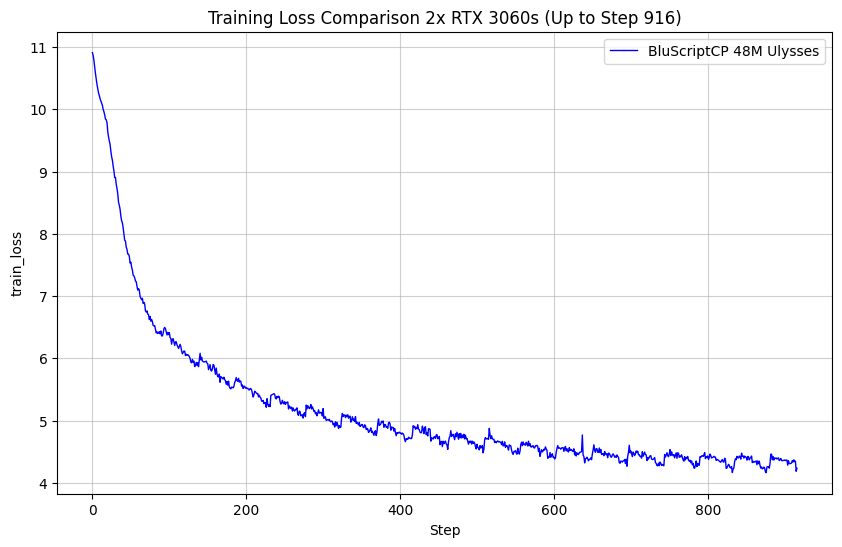

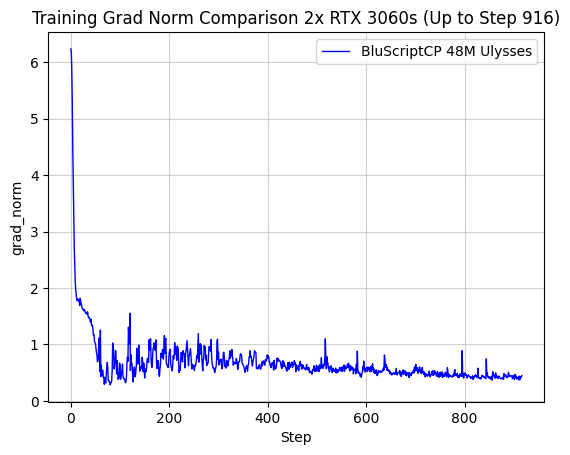

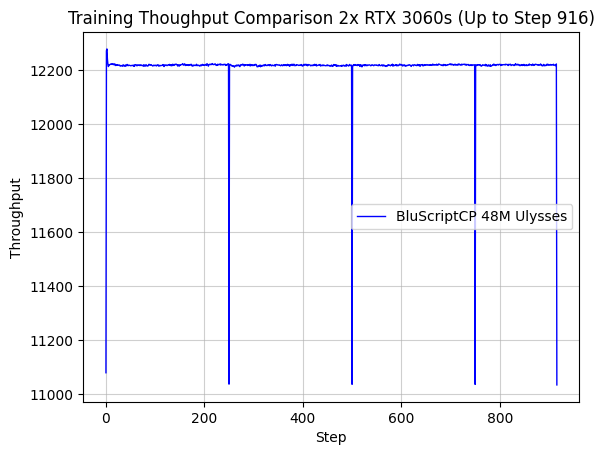

Max. Throughput BluScriptCP 48M Ulysses: 12279.284811
Avg. Throughput BluScriptCP 48M Ulysses: 12212.942597716466
Min Train Loss BluScriptCP 48M Ulysses: 4.162332
Min Val Loss BluScriptCP 48M Ulysses: 4.320529
Avg. Time BluScriptCP 48M Ulysses: 42931.273914587786
Avg. Data Time BluScriptCP 48M Ulysses: 7.105846960741548
Avg. Forward Time BluScriptCP 48M Ulysses: 14589.952066023992
Avg. Loss Time BluScriptCP 48M Ulysses: 156.47958092911668
Avg. Backward Time BluScriptCP 48M Ulysses: 28139.348524432935


In [30]:

import pandas as pd
import matplotlib.pyplot as plt


# Load datasets
df_new = pd.read_csv('/home/blu-bridge25/CP/CP_Training_logs/CP_Training_log4.csv')

if not df_new.empty:
    df_new.columns = df_new.columns.str.strip()

current_max_step = df_new['step'].max()


# 3. Plotting
plt.figure(figsize=(10, 6))

plt.plot(df_new['step'], df_new['train_loss'], label='BluScriptCP 48M Ulysses', linewidth=1, color = 'blue')

plt.xlabel('Step')
plt.ylabel('train_loss')
plt.title(f'Training Loss Comparison 2x RTX 3060s (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)


plt.savefig('comparison_curve.png')
plt.show()

plt.plot(df_new['step'], df_new['grad_norm'], label='BluScriptCP 48M Ulysses', linewidth=1, color = 'blue')


plt.xlabel('Step')
plt.ylabel('grad_norm')
plt.title(f'Training Grad Norm Comparison 2x RTX 3060s (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)

plt.show()

plt.plot(df_new['step'], df_new['tok_per_sec'], label='BluScriptCP 48M Ulysses', linewidth=1, color = 'blue')

plt.xlabel('Step')
plt.ylabel('Throughput')
plt.title(f'Training Thoughput Comparison 2x RTX 3060s (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)
plt.savefig('comparison_curve.png')
plt.show()

print("Max. Throughput BluScriptCP 48M Ulysses:",df_new['tok_per_sec'].max())
print("Avg. Throughput BluScriptCP 48M Ulysses:",df_new['tok_per_sec'].mean())
print("Min Train Loss BluScriptCP 48M Ulysses:",df_new['train_loss'][:].min())
print("Min Val Loss BluScriptCP 48M Ulysses:",df_new['val_loss'].where(df_new['val_loss']!=(-1)).min())
print("Avg. Time BluScriptCP 48M Ulysses:",df_new['dt_ms'].mean())
print("Avg. Data Time BluScriptCP 48M Ulysses:",df_new['timer_data'][:].mean())
print("Avg. Forward Time BluScriptCP 48M Ulysses:",df_new['timer_fwd'][:].mean())
print("Avg. Loss Time BluScriptCP 48M Ulysses:",df_new['timer_loss'][:].mean())
print("Avg. Backward Time BluScriptCP 48M Ulysses:",df_new['timer_bwd'][:].mean())


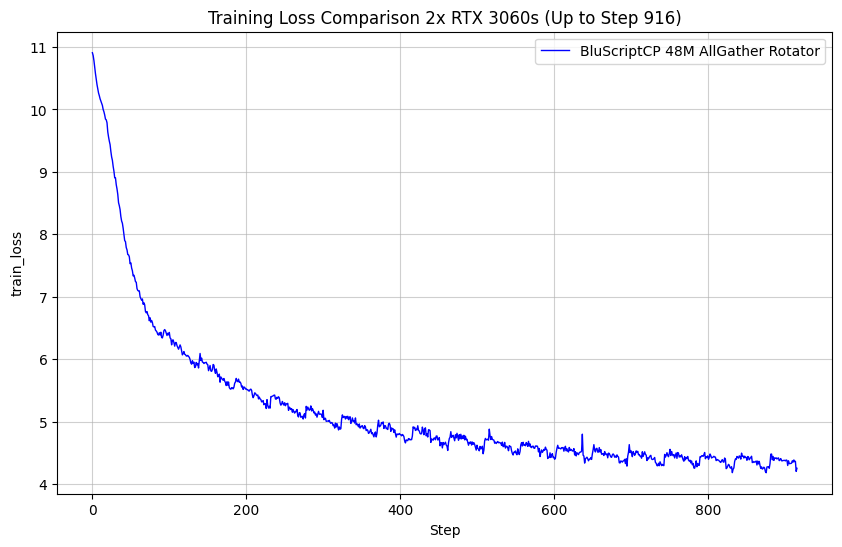

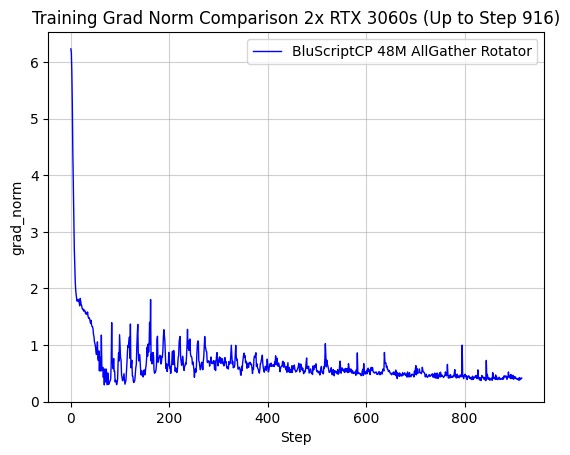

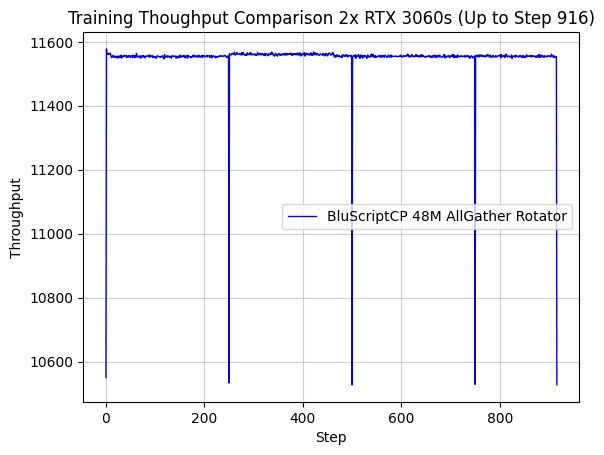

Max. Throughput BluScriptCP 48M AllGather Rotator: 11577.762832
Avg. Throughput BluScriptCP 48M AllGather Rotator: 11550.613233285716
Min Train Loss BluScriptCP 48M AllGather Rotator: 4.181731
Min Val Loss BluScriptCP 48M AllGather Rotator: 4.338413
Avg. Time BluScriptCP 48M AllGather Rotator: 45392.61056349182
Avg. Data Time BluScriptCP 48M AllGather Rotator: 7.882551589967284
Avg. Forward Time BluScriptCP 48M AllGather Rotator: 13997.83515306325
Avg. Loss Time BluScriptCP 48M AllGather Rotator: 156.10706172300982
Avg. Backward Time BluScriptCP 48M AllGather Rotator: 31194.899093907305


In [1]:

import pandas as pd
import matplotlib.pyplot as plt


# Load datasets
df_new = pd.read_csv('/home/blu-bridge25/CP/CP_Training_logs/CP_Training_log7.csv')

if not df_new.empty:
    df_new.columns = df_new.columns.str.strip()

current_max_step = df_new['step'].max()


# 3. Plotting
plt.figure(figsize=(10, 6))

plt.plot(df_new['step'], df_new['train_loss'], label='BluScriptCP 48M AllGather Rotator', linewidth=1, color = 'blue')

plt.xlabel('Step')
plt.ylabel('train_loss')
plt.title(f'Training Loss Comparison 2x RTX 3060s (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)


plt.savefig('comparison_curve.png')
plt.show()

plt.plot(df_new['step'], df_new['grad_norm'], label='BluScriptCP 48M AllGather Rotator', linewidth=1, color = 'blue')


plt.xlabel('Step')
plt.ylabel('grad_norm')
plt.title(f'Training Grad Norm Comparison 2x RTX 3060s (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)

plt.show()

plt.plot(df_new['step'], df_new['tok_per_sec'], label='BluScriptCP 48M AllGather Rotator', linewidth=1, color = 'blue')

plt.xlabel('Step')
plt.ylabel('Throughput')
plt.title(f'Training Thoughput Comparison 2x RTX 3060s (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)
plt.savefig('comparison_curve.png')
plt.show()

print("Max. Throughput BluScriptCP 48M AllGather Rotator:",df_new['tok_per_sec'].max())
print("Avg. Throughput BluScriptCP 48M AllGather Rotator:",df_new['tok_per_sec'].mean())
print("Min Train Loss BluScriptCP 48M AllGather Rotator:",df_new['train_loss'][:].min())
print("Min Val Loss BluScriptCP 48M AllGather Rotator:",df_new['val_loss'].where(df_new['val_loss']!=(-1)).min())
print("Avg. Time BluScriptCP 48M AllGather Rotator:",df_new['dt_ms'].mean())
print("Avg. Data Time BluScriptCP 48M AllGather Rotator:",df_new['timer_data'][:].mean())
print("Avg. Forward Time BluScriptCP 48M AllGather Rotator:",df_new['timer_fwd'][:].mean())
print("Avg. Loss Time BluScriptCP 48M AllGather Rotator:",df_new['timer_loss'][:].mean())
print("Avg. Backward Time BluScriptCP 48M AllGather Rotator:",df_new['timer_bwd'][:].mean())


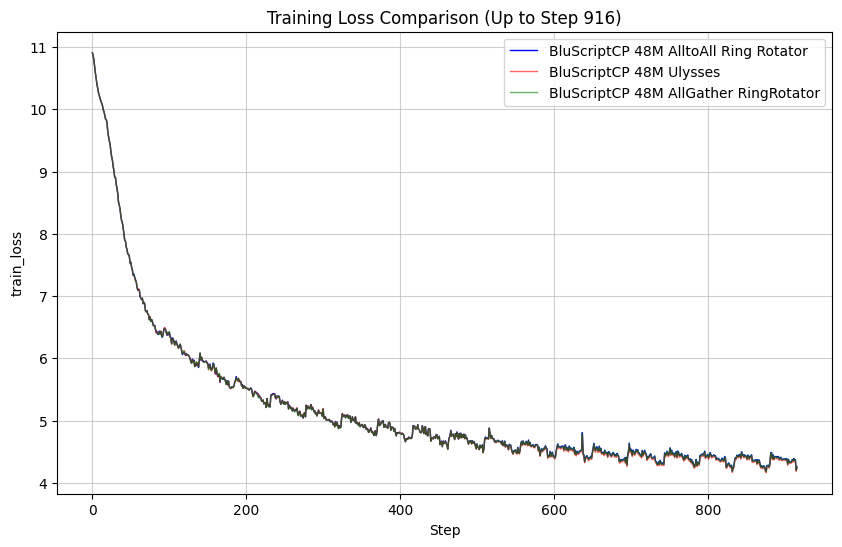

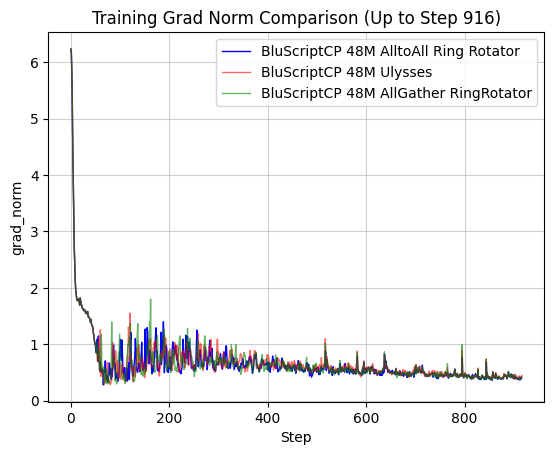

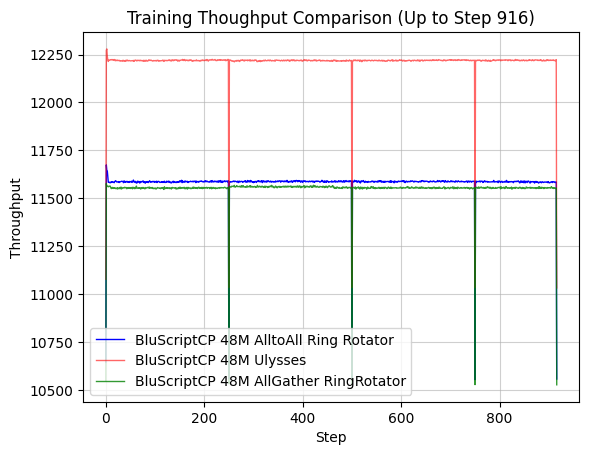

Max. Throughput BluScriptCP 48M AlltoAll Ring Rotator: 11674.623382
Avg. Throughput BluScriptCP 48M AlltoAll Ring Rotator: 11582.07168025736
Min Train Loss BluScriptCP 48M AlltoAll Ring Rotator: 4.187034
Min Val Loss BluScriptCP 48M AlltoAll Ring Rotator: 4.342005
Avg. Time BluScriptCP 48M AlltoAll Ring Rotator: 45269.26466228026
Avg. Data Time BluScriptCP 48M AlltoAll Ring Rotator: 8.928428597600872
Avg. Forward Time BluScriptCP 48M AlltoAll Ring Rotator: 13955.531257437297
Avg. Loss Time BluScriptCP 48M AlltoAll Ring Rotator: 156.2313310883315
Avg. Backward Time BluScriptCP 48M AlltoAll Ring Rotator: 31112.237717525626

Max. Throughput BluScriptCP 48M Ulysses: 12279.284811
Avg. Throughput BluScriptCP 48M Ulysses: 12212.942597716466
Min Train Loss BluScriptCP 48M Ulysses: 4.162332
Min Val Loss BluScriptCP 48M Ulysses: 4.320529
Avg. Time BluScriptCP 48M Ulysses: 42931.273914587786
Avg. Data Time BluScriptCP 48M Ulysses: 7.105846960741548
Avg. Forward Time BluScriptCP 48M Ulysses: 14589

: 

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

# plt.style.use('')

# Load datasets
df_new = pd.read_csv('/home/blu-bridge25/CP/CP_Training_logs/CP_Training_log1.csv')
df_old = pd.read_csv('/home/blu-bridge25/CP/CP_Training_logs/CP_Training_log4.csv')
df_3rd = pd.read_csv('/home/blu-bridge25/CP/CP_Training_logs/CP_Training_log7.csv')

if not df_new.empty:
    df_old.columns = df_old.columns.str.strip()
    df_new.columns = df_new.columns.str.strip()
    df_3rd.columns = df_3rd.columns.str.strip()

# 1. Get the current progress (max step of the new run)
current_max_step = df_new['step'].max()

# 2 Filter the old run to match the current progress
df_old_truncated = df_old[df_old['step'] <= current_max_step]
df_3rd_truncated = df_3rd[df_3rd['step'] <= current_max_step]

# 3. Plotting
plt.figure(figsize=(10, 6))

plt.plot(df_new['step'], df_new['train_loss'], label='BluScriptCP 48M AlltoAll Ring Rotator', linewidth=1, color = 'blue')
plt.plot(df_old_truncated['step'], df_old_truncated['train_loss'], label='BluScriptCP 48M Ulysses',linewidth = 1, linestyle = "-", color = "red", alpha=0.6)
plt.plot(df_3rd_truncated['step'], df_3rd_truncated['train_loss'], label='BluScriptCP 48M AllGather RingRotator',linewidth = 1, linestyle = "-", color = "green", alpha=0.6)

plt.xlabel('Step')
plt.ylabel('train_loss')
plt.title(f'Training Loss Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)


plt.savefig('comparison_curve.png')
plt.show()

plt.plot(df_new['step'], df_new['grad_norm'], label='BluScriptCP 48M AlltoAll Ring Rotator', linewidth=1, color = 'blue')
plt.plot(df_old_truncated['step'], df_old_truncated['grad_norm'], label='BluScriptCP 48M Ulysses',linewidth = 1, linestyle = "-", color = "red", alpha=0.6)
plt.plot(df_3rd_truncated['step'], df_3rd_truncated['grad_norm'], label='BluScriptCP 48M AllGather RingRotator',linewidth = 1, linestyle = "-", color = "green", alpha=0.6)


plt.xlabel('Step')
plt.ylabel('grad_norm')
plt.title(f'Training Grad Norm Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)

plt.show()

plt.plot(df_new['step'], df_new['tok_per_sec'], label='BluScriptCP 48M AlltoAll Ring Rotator', linewidth=1, color = 'blue')
plt.plot(df_old_truncated['step'], df_old_truncated['tok_per_sec'], label='BluScriptCP 48M Ulysses',linewidth=1, linestyle = "-", color = "red", alpha=0.6)
plt.plot(df_3rd_truncated['step'], df_3rd_truncated['tok_per_sec'], label='BluScriptCP 48M AllGather RingRotator',linewidth = 1, linestyle = "-", color = "green", alpha=0.8)

plt.xlabel('Step')
plt.ylabel('Throughput')
plt.title(f'Training Thoughput Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)
plt.savefig('comparison_curve.png')
plt.show()

print("Max. Throughput BluScriptCP 48M AlltoAll Ring Rotator:",df_new['tok_per_sec'].max())
print("Avg. Throughput BluScriptCP 48M AlltoAll Ring Rotator:",df_new['tok_per_sec'].mean())
print("Min Train Loss BluScriptCP 48M AlltoAll Ring Rotator:",df_new['train_loss'][:].min())
print("Min Val Loss BluScriptCP 48M AlltoAll Ring Rotator:",df_new['val_loss'].where(df_new['val_loss']!=(-1)).min())
print("Avg. Time BluScriptCP 48M AlltoAll Ring Rotator:",df_new['dt_ms'].mean())
print("Avg. Data Time BluScriptCP 48M AlltoAll Ring Rotator:",df_new['timer_data'][:].mean())
print("Avg. Forward Time BluScriptCP 48M AlltoAll Ring Rotator:",df_new['timer_fwd'][:].mean())
print("Avg. Loss Time BluScriptCP 48M AlltoAll Ring Rotator:",df_new['timer_loss'][:].mean())
print("Avg. Backward Time BluScriptCP 48M AlltoAll Ring Rotator:",df_new['timer_bwd'][:].mean())
# print("Avg. Attention Time BluScriptCP 48M AlltoAll Ring Rotator:",df_new['timer_attn_cp'][:].mean())
# print("Avg. clip_grad Time BluScriptCP 48M AlltoAll Ring Rotator:",df_new['timer_clip'][:].mean())
# print("Avg. Optimizer Time BluScriptCP 48M AlltoAll Ring Rotator:",df_new['timer_optim'][:].mean())
# print("Avg. Tok_Emb Time BluScriptCP 48M AlltoAll Ring Rotator:",df_new['timer_tok_emb'][:].mean())
# print("Avg. Pos_Emb Time BluScriptCP 48M AlltoAll Ring Rotator:",df_new['timer_pos_emb'].mean())
# print("Avg. Mlp Time BluScriptCP 48M AlltoAll Ring Rotator:",df_new['timer_mlp'][:].mean())
# print("Avg. Ln_f Time BluScriptCP 48M AlltoAll Ring Rotator:",df_new['timer_ln_f'][:].mean())
# print("Avg. LM Head Time BluScriptCP 48M AlltoAll Ring Rotator:",df_new['timer_lm_head'][:].mean())


print("\nMax. Throughput BluScriptCP 48M Ulysses:",df_old_truncated['tok_per_sec'].max())
print("Avg. Throughput BluScriptCP 48M Ulysses:",df_old_truncated['tok_per_sec'].mean())
print("Min Train Loss BluScriptCP 48M Ulysses:",df_old_truncated['train_loss'][:].min())
print("Min Val Loss BluScriptCP 48M Ulysses:",df_old_truncated['val_loss'].where(df_old_truncated['val_loss']!=(-1)).min())
print("Avg. Time BluScriptCP 48M Ulysses:",df_old_truncated['dt_ms'].mean())
print("Avg. Data Time BluScriptCP 48M Ulysses:",df_old_truncated['timer_data'][:].mean())
print("Avg. Forward Time BluScriptCP 48M Ulysses:",df_old_truncated['timer_fwd'][:].mean())
print("Avg. Loss Time BluScriptCP 48M Ulysses:",df_old_truncated['timer_loss'][:].mean())
print("Avg. Backward Time BluScriptCP 48M Ulysses:",df_old_truncated['timer_bwd'][:].mean())
# print("Avg. Attention Time BluScriptCP 48M Ulysses:",df_old_truncated['timer_attn_cp'][:].mean())
# print("Avg. clip_grad Time BluScriptCP 48M Ulysses:",df_old_truncated['timer_clip'][:].mean())
# print("Avg. Optimizer Time BluScriptCP 48M Ulysses:",df_old_truncated['timer_optim'][:].mean())
# print("Avg. Tok_Emb Time BluScriptCP 48M Ulysses:",df_old_truncated['timer_tok_emb'][:].mean())
# print("Avg. Pos_Emb Time BluScriptCP 48M Ulysses:",df_old_truncated['timer_pos_emb'].mean())
# print("Avg. Mlp Time BluScriptCP 48M Ulysses:",df_old_truncated['timer_mlp'][:].mean())
# print("Avg. Ln_f Time BluScriptCP 48M Ulysses:",df_old_truncated['timer_ln_f'][:].mean())
# print("Avg. LM Head Time BluScriptCP 48M Ulysses:",df_old_truncated['timer_lm_head'][:].mean())



print("\nMax. Throughput BluScriptCP 48M AllGather RingRotator:",df_3rd_truncated['tok_per_sec'].max())
print("Avg. Throughput BluScriptCP 48M AllGather RingRotator:",df_3rd_truncated['tok_per_sec'].mean())
print("Min Train Loss BluScriptCP 48M AllGather RingRotator:",df_3rd_truncated['train_loss'][:].min())
print("Min Val Loss BluScriptCP 48M AllGather RingRotator:",df_3rd_truncated['val_loss'].where(df_3rd_truncated['val_loss']!=(-1)).min())
print("Avg. Time BluScriptCP 48M AllGather RingRotator:",df_3rd_truncated['dt_ms'].mean())
print("Avg. Data Time BluScriptCP 48M AllGather RingRotator:",df_3rd_truncated['timer_data'][:].mean())
print("Avg. Forward Time BluScriptCP 48M AllGather RingRotator:",df_3rd_truncated['timer_fwd'][:].mean())
print("Avg. Loss Time BluScriptCP 48M AllGather RingRotator:",df_3rd_truncated['timer_loss'][:].mean())
print("Avg. Backward Time BluScriptCP 48M AllGather RingRotator:",df_3rd_truncated['timer_bwd'][:].mean())
# print("Avg. Attention Time BluScriptCP 48M AllGather RingRotator:",df_3rd_truncated['timer_attn_cp'][:].mean())
# print("Avg. clip_grad Time BluScriptCP 48M AllGather RingRotator:",df_3rd_truncated['timer_clip'][:].mean())
# print("Avg. Optimizer Time BluScriptCP 48M AllGather RingRotator:",df_3rd_truncated['timer_optim'][:].mean())
# print("Avg. Tok_Emb Time BluScriptCP 48M AllGather RingRotator:",df_3rd_truncated['timer_tok_emb'][:].mean())
# print("Avg. Pos_Emb Time BluScriptCP 48M AllGather RingRotator:",df_3rd_truncated['timer_pos_emb'].mean())
# print("Avg. Mlp Time BluScriptCP 48M AllGather RingRotator:",df_3rd_truncated['timer_mlp'][:].mean())
# print("Avg. Ln_f Time BluScriptCP 48M AllGather RingRotator:",df_3rd_truncated['timer_ln_f'][:].mean())
# print("Avg. LM Head Time BluScriptCP 48M AllGather RingRotator:",df_3rd_truncated['timer_lm_head'][:].mean())

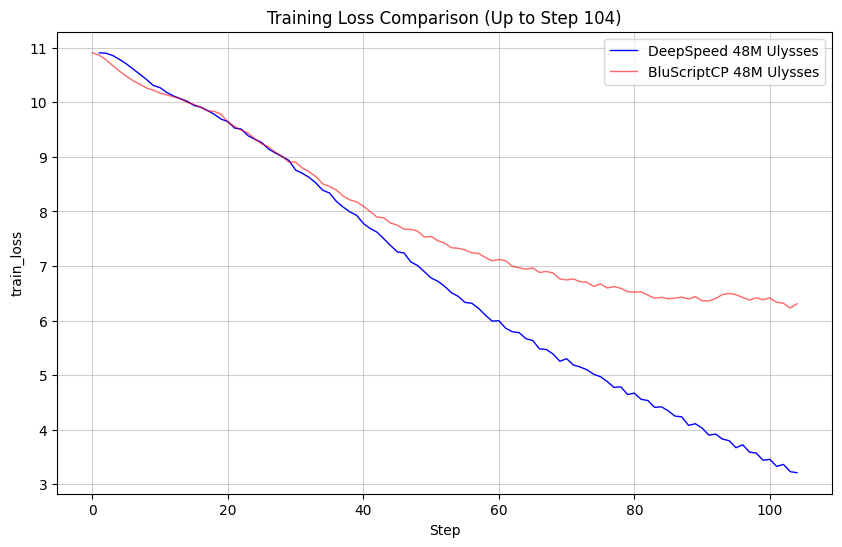

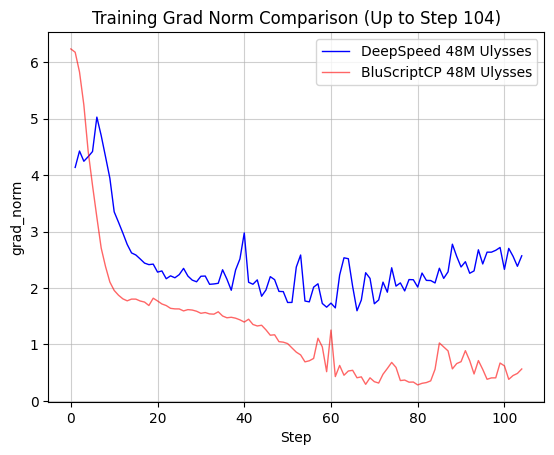

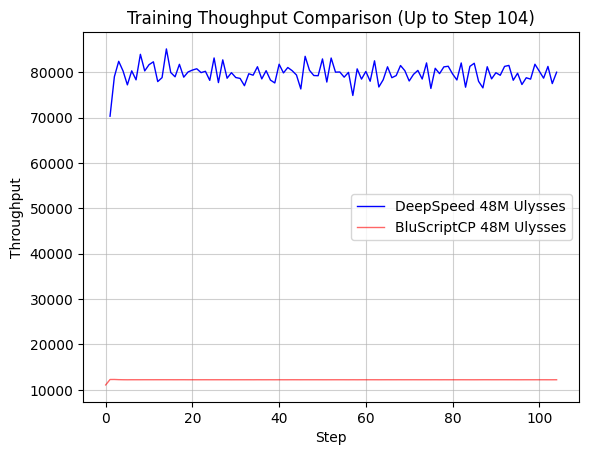

Max. Throughput DeepSpeed 48M Ulysses: 85172.3
Avg. Throughput DeepSpeed 48M Ulysses: 79744.66057692307
Min Train Loss DeepSpeed 48M Ulysses: 3.209707
Min Val Loss DeepSpeed 48M Ulysses: nan
Avg. Time DeepSpeed 48M Ulysses: 6578.999653846153
Avg. Data Time DeepSpeed 48M Ulysses: 378.4702019230769
Avg. Forward Time DeepSpeed 48M Ulysses: 1486.8837403846153
Avg. Loss Time DeepSpeed 48M Ulysses: 0.0
Avg. Backward Time DeepSpeed 48M Ulysses: 5066.34585576923

Max. Throughput BluScriptCP 48M Ulysses: 12279.284811
Avg. Throughput BluScriptCP 48M Ulysses: 12209.196825828572
Min Train Loss BluScriptCP 48M Ulysses: 6.227677
Min Val Loss BluScriptCP 48M Ulysses: 10.905594
Avg. Time BluScriptCP 48M Ulysses: 42945.97686007619
Avg. Data Time BluScriptCP 48M Ulysses: 5.029485704761905
Avg. Forward Time BluScriptCP 48M Ulysses: 14589.048839009522
Avg. Loss Time BluScriptCP 48M Ulysses: 156.51612645714283
Avg. Backward Time BluScriptCP 48M Ulysses: 28136.84794569524


NameError: name 'df_d_truncated' is not defined

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

# plt.style.use('')

# Load datasets
df_new = pd.read_csv('/home/blu-bridge25/LlamaFactory/outputs/qwen3_48m_pt_fsdp2_ulysses/training_log.csv')
df_old = pd.read_csv('/home/blu-bridge25/CP/CP_Training_logs/CP_Training_log4.csv')
# df_d = pd.read_csv('/home/blu-bridge25/CP/CP_Training_logs/CP_Training_log7.csv')

if not df_new.empty:
    df_old.columns = df_old.columns.str.strip()
    df_new.columns = df_new.columns.str.strip()
    # # df_d.columns = df_d.columns.str.strip()

# 1. Get the current progress (max step of the new run)
current_max_step = df_new['step'].max()

# 2 Filter the old run to match the current progress
df_old_truncated = df_old[df_old['step'] <= current_max_step]
# # # df_d_truncated = df_d[df_d['step'] <= current_max_step]

# 3. Plotting
plt.figure(figsize=(10, 6))

plt.plot(df_new['step'], df_new['train_loss'], label='DeepSpeed 48M Ulysses', linewidth=1, color = 'blue')
plt.plot(df_old_truncated['step'], df_old_truncated['train_loss'], label='BluScriptCP 48M Ulysses',linewidth = 1, linestyle = "-", color = "red", alpha=0.6)
# # plt.plot(df_d_truncated['step'], df_d_truncated['train_loss'], label='BluScriptCP 48M AllGather RingRotator',linewidth = 1, linestyle = "-", color = "green", alpha=0.6)

plt.xlabel('Step')
plt.ylabel('train_loss')
plt.title(f'Training Loss Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)


plt.savefig('comparison_curve.png')
plt.show()

plt.plot(df_new['step'], df_new['grad_norm'], label='DeepSpeed 48M Ulysses', linewidth=1, color = 'blue')
plt.plot(df_old_truncated['step'], df_old_truncated['grad_norm'], label='BluScriptCP 48M Ulysses',linewidth = 1, linestyle = "-", color = "red", alpha=0.6)
# # plt.plot(df_d_truncated['step'], df_d_truncated['grad_norm'], label='BluScriptCP 48M AllGather RingRotator',linewidth = 1, linestyle = "-", color = "green", alpha=0.6)


plt.xlabel('Step')
plt.ylabel('grad_norm')
plt.title(f'Training Grad Norm Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)

plt.show()

plt.plot(df_new['step'], df_new['tok_per_sec'], label='DeepSpeed 48M Ulysses', linewidth=1, color = 'blue')
plt.plot(df_old_truncated['step'], df_old_truncated['tok_per_sec'], label='BluScriptCP 48M Ulysses',linewidth=1, linestyle = "-", color = "red", alpha=0.6)
# # plt.plot(df_d_truncated['step'], df_d_truncated['tok_per_sec'], label='BluScriptCP 48M AllGather RingRotator',linewidth = 1, linestyle = "-", color = "green", alpha=0.8)

plt.xlabel('Step')
plt.ylabel('Throughput')
plt.title(f'Training Thoughput Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)
plt.savefig('comparison_curve.png')
plt.show()

print("Max. Throughput DeepSpeed 48M Ulysses:",df_new['tok_per_sec'].max())
print("Avg. Throughput DeepSpeed 48M Ulysses:",df_new['tok_per_sec'].mean())
print("Min Train Loss DeepSpeed 48M Ulysses:",df_new['train_loss'][:].min())
print("Min Val Loss DeepSpeed 48M Ulysses:",df_new['val_loss'].where(df_new['val_loss']!=(-1)).min())
print("Avg. Time DeepSpeed 48M Ulysses:",df_new['dt_ms'].mean())
print("Avg. Data Time DeepSpeed 48M Ulysses:",df_new['timer_data'][:].mean())
print("Avg. Forward Time DeepSpeed 48M Ulysses:",df_new['timer_fwd'][:].mean())
print("Avg. Loss Time DeepSpeed 48M Ulysses:",df_new['timer_loss'][:].mean())
print("Avg. Backward Time DeepSpeed 48M Ulysses:",df_new['timer_bwd'][:].mean())
# print("Avg. Attention Time DeepSpeed 48M Ulysses:",df_new['timer_attn_cp'][:].mean())
# print("Avg. clip_grad Time DeepSpeed 48M Ulysses:",df_new['timer_clip'][:].mean())
# print("Avg. Optimizer Time DeepSpeed 48M Ulysses:",df_new['timer_optim'][:].mean())
# print("Avg. Tok_Emb Time DeepSpeed 48M Ulysses:",df_new['timer_tok_emb'][:].mean())
# print("Avg. Pos_Emb Time DeepSpeed 48M Ulysses:",df_new['timer_pos_emb'].mean())
# print("Avg. Mlp Time DeepSpeed 48M Ulysses:",df_new['timer_mlp'][:].mean())
# print("Avg. Ln_f Time DeepSpeed 48M Ulysses:",df_new['timer_ln_f'][:].mean())
# print("Avg. LM Head Time DeepSpeed 48M Ulysses:",df_new['timer_lm_head'][:].mean())


print("\nMax. Throughput BluScriptCP 48M Ulysses:",df_old_truncated['tok_per_sec'].max())
print("Avg. Throughput BluScriptCP 48M Ulysses:",df_old_truncated['tok_per_sec'].mean())
print("Min Train Loss BluScriptCP 48M Ulysses:",df_old_truncated['train_loss'][:].min())
print("Min Val Loss BluScriptCP 48M Ulysses:",df_old_truncated['val_loss'].where(df_old_truncated['val_loss']!=(-1)).min())
print("Avg. Time BluScriptCP 48M Ulysses:",df_old_truncated['dt_ms'].mean())
print("Avg. Data Time BluScriptCP 48M Ulysses:",df_old_truncated['timer_data'][:].mean())
print("Avg. Forward Time BluScriptCP 48M Ulysses:",df_old_truncated['timer_fwd'][:].mean())
print("Avg. Loss Time BluScriptCP 48M Ulysses:",df_old_truncated['timer_loss'][:].mean())
print("Avg. Backward Time BluScriptCP 48M Ulysses:",df_old_truncated['timer_bwd'][:].mean())
# print("Avg. Attention Time BluScriptCP 48M Ulysses:",df_old_truncated['timer_attn_cp'][:].mean())
# print("Avg. clip_grad Time BluScriptCP 48M Ulysses:",df_old_truncated['timer_clip'][:].mean())
# print("Avg. Optimizer Time BluScriptCP 48M Ulysses:",df_old_truncated['timer_optim'][:].mean())
# print("Avg. Tok_Emb Time BluScriptCP 48M Ulysses:",df_old_truncated['timer_tok_emb'][:].mean())
# print("Avg. Pos_Emb Time BluScriptCP 48M Ulysses:",df_old_truncated['timer_pos_emb'].mean())
# print("Avg. Mlp Time BluScriptCP 48M Ulysses:",df_old_truncated['timer_mlp'][:].mean())
# print("Avg. Ln_f Time BluScriptCP 48M Ulysses:",df_old_truncated['timer_ln_f'][:].mean())
# print("Avg. LM Head Time BluScriptCP 48M Ulysses:",df_old_truncated['timer_lm_head'][:].mean())



# print("\nMax. Throughput BluScriptCP 48M AllGather RingRotator:",df_d_truncated['tok_per_sec'].max())
# print("Avg. Throughput BluScriptCP 48M AllGather RingRotator:",df_d_truncated['tok_per_sec'].mean())
# print("Min Train Loss BluScriptCP 48M AllGather RingRotator:",df_d_truncated['train_loss'][:].min())
# # print("Min Val Loss BluScriptCP 48M AllGather RingRotator:",df_d_truncated['val_loss'].where(df_d_truncated['val_loss']!=(-1)).min())
# print("Avg. Time BluScriptCP 48M AllGather RingRotator:",df_d_truncated['dt_ms'].mean())
# print("Avg. Data Time BluScriptCP 48M AllGather RingRotator:",df_d_truncated['timer_data'][:].mean())
# print("Avg. Forward Time BluScriptCP 48M AllGather RingRotator:",df_d_truncated['timer_fwd'][:].mean())
# print("Avg. Loss Time BluScriptCP 48M AllGather RingRotator:",df_d_truncated['timer_loss'][:].mean())
# print("Avg. Backward Time BluScriptCP 48M AllGather RingRotator:",df_d_truncated['timer_bwd'][:].mean())
# print("Avg. Attention Time BluScriptCP 48M AllGather RingRotator:",df_d_truncated['timer_attn_cp'][:].mean())
# print("Avg. clip_grad Time BluScriptCP 48M AllGather RingRotator:",df_d_truncated['timer_clip'][:].mean())
# print("Avg. Optimizer Time BluScriptCP 48M AllGather RingRotator:",df_d_truncated['timer_optim'][:].mean())
# print("Avg. Tok_Emb Time BluScriptCP 48M AllGather RingRotator:",df_d_truncated['timer_tok_emb'][:].mean())
# print("Avg. Pos_Emb Time BluScriptCP 48M AllGather RingRotator:",df_d_truncated['timer_pos_emb'].mean())
# print("Avg. Mlp Time BluScriptCP 48M AllGather RingRotator:",df_d_truncated['timer_mlp'][:].mean())
# print("Avg. Ln_f Time BluScriptCP 48M AllGather RingRotator:",df_d_truncated['timer_ln_f'][:].mean())
# print("Avg. LM Head Time BluScriptCP 48M AllGather RingRotator:",df_d_truncated['timer_lm_head'][:].mean())